# Classification Track — Used Car Price Category
23CSE301 ML Capstone — Part A (Review 1) + Part B (Review 2)

Same source dataset as the regression track (`data/raw/autos.csv`), reframed as a **4-class classification problem**: predicting a car's price bracket — `Budget` / `Economy` / `Premium` / `Luxury` — from its listing attributes.

**Structure below follows the rubric sections directly:** Section A (Dataset & EDA), Section B (Preprocessing & Feature Engineering), Section D (Classification Track Part A — Review 1). Part B (Section A of the Review 2 rubric) is stubbed at the end.

**Review 1 scope:** Part A — Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVC (5 algorithms).

## Section A — Dataset & EDA

### A1. Dataset Loading & Audit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

df = pd.read_csv("../data/raw/autos.csv", encoding="latin-1")
print("Shape:", df.shape)
df.info()

Shape: (371528, 21)
<class 'pandas.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   index                371528 non-null  int64
 1   dateCrawled          371528 non-null  str  
 2   name                 371528 non-null  str  
 3   seller               371528 non-null  str  
 4   offerType            371528 non-null  str  
 5   price                371528 non-null  int64
 6   abtest               371528 non-null  str  
 7   vehicleType          333659 non-null  str  
 8   yearOfRegistration   371528 non-null  int64
 9   gearbox              351319 non-null  str  
 10  powerPS              371528 non-null  int64
 11  model                351044 non-null  str  
 12  kilometer            371528 non-null  int64
 13  monthOfRegistration  371528 non-null  int64
 14  fuelType             338142 non-null  str  
 15  brand                371528 non-null  str 

In [2]:
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))

Missing values per column:


notRepairedDamage      72060
vehicleType            37869
fuelType               33386
model                  20484
gearbox                20209
offerType                  0
seller                     0
name                       0
dateCrawled                0
index                      0
abtest                     0
yearOfRegistration         0
price                      0
kilometer                  0
powerPS                    0
monthOfRegistration        0
brand                      0
dateCreated                0
nrOfPictures               0
postalCode                 0
lastSeen                   0
dtype: int64


**Observation:** same raw dataset as the regression track — ~371k listings, with missingness concentrated in `vehicleType`, `gearbox`, `model`, `fuelType`, and `notRepairedDamage`. The classification target (`price_category`) is derived from `price` after cleaning, in Section B.

### A2. EDA Visualisations

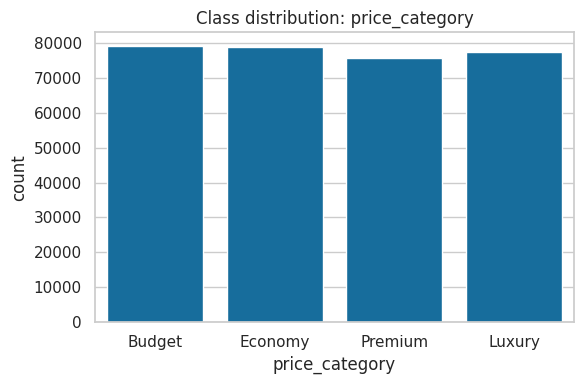

price_category
Budget     79197
Economy    78984
Luxury     77639
Premium    75820
Name: count, dtype: int64


In [3]:
df_eda = df[(df["price"] >= 100) & (df["price"] <= 150000)]
df_eda = df_eda[(df_eda["yearOfRegistration"] >= 1950) & (df_eda["yearOfRegistration"] <= 2016)]
df_eda = df_eda[(df_eda["powerPS"] > 0) & (df_eda["powerPS"] <= 1000)]

df_eda = df_eda.copy()
df_eda["price_category"] = pd.qcut(df_eda["price"], q=4, labels=["Budget", "Economy", "Premium", "Luxury"])

plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x="price_category", order=["Budget", "Economy", "Premium", "Luxury"])
plt.title("Class distribution: price_category")
plt.tight_layout()
plt.show()
print(df_eda["price_category"].value_counts())

**Insight (A3):** quartile-based binning produces four roughly balanced classes (~93k listings each out of ~372k), which avoids the class-imbalance issues a natural price cutoff might introduce and keeps `Accuracy` a meaningful headline metric alongside F1/ROC-AUC.

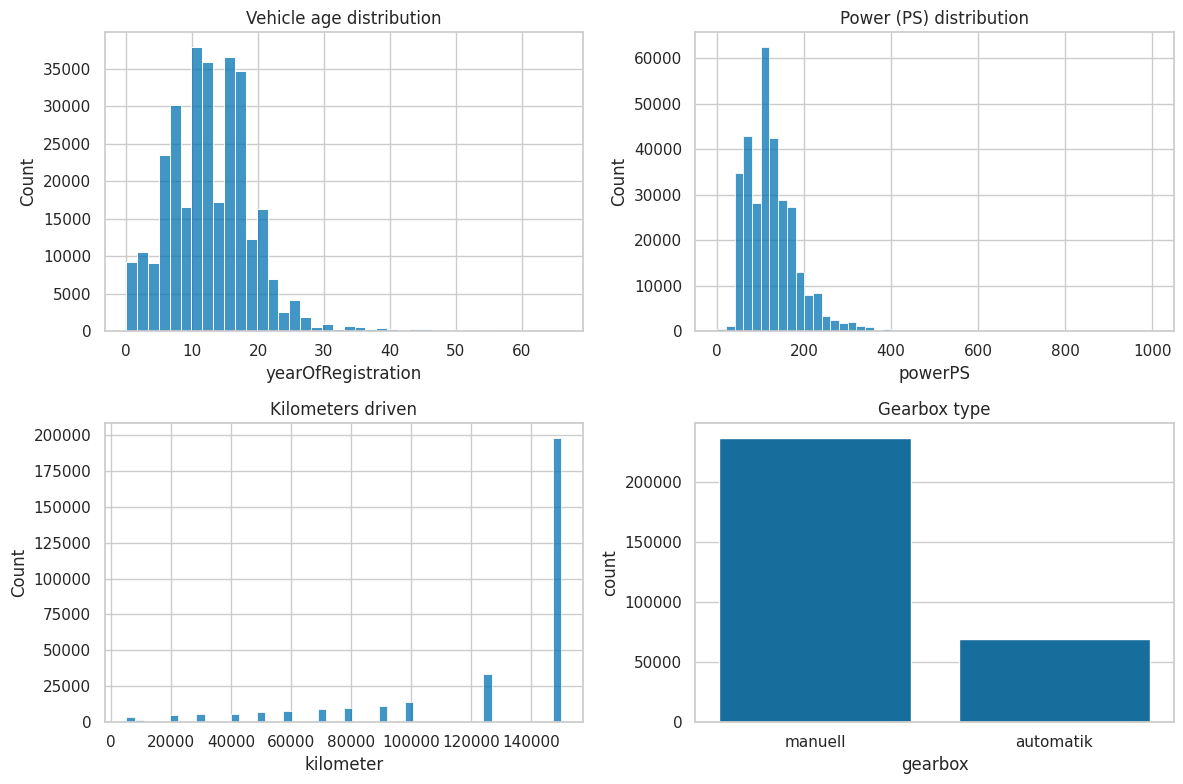

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(2016 - df_eda["yearOfRegistration"], bins=40, ax=axes[0,0]).set_title("Vehicle age distribution")
sns.histplot(df_eda["powerPS"], bins=50, ax=axes[0,1]).set_title("Power (PS) distribution")
sns.histplot(df_eda["kilometer"], bins=50, ax=axes[1,0]).set_title("Kilometers driven")
sns.countplot(data=df_eda, x="gearbox", ax=axes[1,1]).set_title("Gearbox type")
plt.tight_layout()
plt.show()

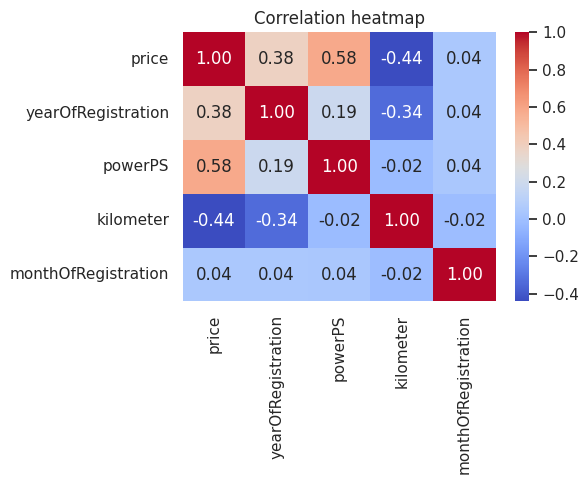

In [5]:
numeric_cols = ["price", "yearOfRegistration", "powerPS", "kilometer", "monthOfRegistration"]
plt.figure(figsize=(6, 5))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

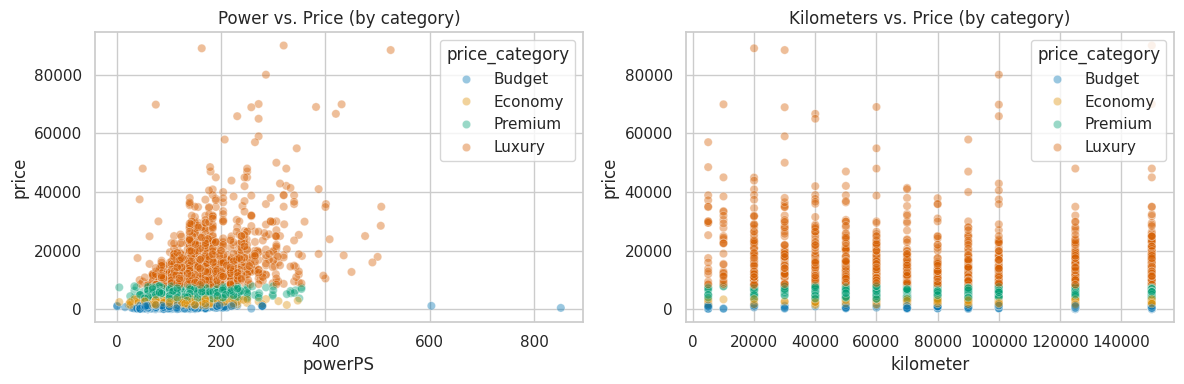

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = df_eda.sample(5000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="powerPS", y="price", hue="price_category", alpha=0.4, ax=axes[0]).set_title("Power vs. Price (by category)")
sns.scatterplot(data=sample, x="kilometer", y="price", hue="price_category", alpha=0.4, ax=axes[1]).set_title("Kilometers vs. Price (by category)")
plt.tight_layout()
plt.show()

**Insight (A3):** `Luxury`-category cars cluster at high power and low-to-moderate mileage; `Budget` cars span the full mileage range but are concentrated at low power. This separability by `powerPS` and `kilometer` is a good early signal that the classifiers below should be able to distinguish the categories reasonably well.

## Section B — Preprocessing & Feature Engineering

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- B1. Cleaning (same rules as the regression track, for a fair, consistent basis) ---
df_clean = df[(df["price"] >= 100) & (df["price"] <= 150000)]
df_clean = df_clean[(df_clean["yearOfRegistration"] >= 1950) & (df_clean["yearOfRegistration"] <= 2016)]
df_clean = df_clean[(df_clean["powerPS"] > 0) & (df_clean["powerPS"] <= 1000)]
df_clean = df_clean.drop_duplicates(subset=[c for c in df_clean.columns if c != "index"])

drop_cols = ["index", "dateCrawled", "name", "nrOfPictures", "postalCode", "dateCreated", "lastSeen", "offerType", "abtest", "seller"]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
df_clean["vehicle_age"] = 2016 - df_clean["yearOfRegistration"]
df_clean = df_clean.reset_index(drop=True)

# --- Target: 4-class price category via quartile binning ---
df_clean["price_category"] = pd.qcut(df_clean["price"], q=4, labels=["Budget", "Economy", "Premium", "Luxury"])

# Subsample for computational feasibility (SVC / MLP do not scale well on limited hardware)
df_model = df_clean.sample(n=8000, random_state=RANDOM_STATE).reset_index(drop=True)

numeric_features = ["vehicle_age", "powerPS", "kilometer", "monthOfRegistration"]
categorical_features = ["vehicleType", "gearbox", "model", "fuelType", "brand", "notRepairedDamage"]

X = df_model[numeric_features + categorical_features]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_model["price_category"])
class_names = label_encoder.classes_
print("Classes:", list(class_names))

# --- B2. Stratified split, then fit scalers/encoders on train only (avoid leakage) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
X_train_dense = X_train_proc.toarray()  # GaussianNB requires dense input
X_test_dense = X_test_proc.toarray()

print("Train shape:", X_train_proc.shape, "Test shape:", X_test_proc.shape)

Classes: ['Budget', 'Economy', 'Luxury', 'Premium']
Train shape: (6400, 285) Test shape: (1600, 285)


**B3 justification:** same `vehicle_age` feature as the regression track (`2016 - yearOfRegistration`), for consistency across tracks and because raw calendar year is less directly interpretable for depreciation-driven price-bracket classification.

## Section D — Classification Track, Part A (Review 1)

### D1. Implementation — Algorithms 1-5

Fill in each `TODO` below with the corresponding model. Use `X_train_proc` / `X_test_proc` for everything **except** Gaussian Naive Bayes, which needs dense input: `X_train_dense` / `X_test_dense`. For ROC-AUC you'll need `predict_proba`, so pass `probability=True` to SVC.

Store every fitted model in `fitted_models[<name>]`, its predictions in `predictions[<name>]`, and its class probabilities in `probabilities[<name>]` — Section D2 reads from these three dicts, so keep the key names exactly as shown.

In [8]:
fitted_models = {}
predictions = {}
probabilities = {}

**1. Logistic Regression** — Baseline classifier; interpret coefficients/odds.

In [9]:
from sklearn.linear_model import LogisticRegression

# TODO: implement Logistic Regression
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)
# fitted_models["Logistic Regression"] = model
# predictions["Logistic Regression"] = pred
# probabilities["Logistic Regression"] = proba


**2. KNN** — Tune k; discuss distance metrics.

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# TODO: implement KNN
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)
# fitted_models["KNN"] = model
# predictions["KNN"] = pred
# probabilities["KNN"] = proba


**3. Gaussian Naive Bayes** — Discuss conditional independence assumption. Needs dense input: X_train_dense / X_test_dense.

In [11]:
from sklearn.naive_bayes import GaussianNB

# TODO: implement Gaussian Naive Bayes
# model = ...
# model.fit(X_train_dense, y_train)
# pred = model.predict(X_test_dense)
# proba = model.predict_proba(X_test_dense)
# fitted_models["Gaussian Naive Bayes"] = model
# predictions["Gaussian Naive Bayes"] = pred
# probabilities["Gaussian Naive Bayes"] = proba


**4. Decision Tree Classifier** — Tune max_depth; visualise the tree.

In [12]:
from sklearn.tree import DecisionTreeClassifier

# TODO: implement Decision Tree Classifier
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)
# fitted_models["Decision Tree Classifier"] = model
# predictions["Decision Tree Classifier"] = pred
# probabilities["Decision Tree Classifier"] = proba


**5. SVC** — Tune C and kernel; scale features. Remember probability=True for ROC-AUC.

In [13]:
from sklearn.svm import SVC

# TODO: implement SVC
# model = ...
# model.fit(X_train_proc, y_train)
# pred = model.predict(X_test_proc)
# proba = model.predict_proba(X_test_proc)
# fitted_models["SVC"] = model
# predictions["SVC"] = pred
# probabilities["SVC"] = proba


### D2. Evaluation

Once all 5 Part-A models above are filled in, this cell builds the comparison table (Accuracy, Precision, Recall, weighted F1, ROC-AUC OvR) and a confusion matrix for the best model.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

rows = []
for name in fitted_models:
    pred = predictions[name]
    proba = probabilities[name]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)": f1_score(y_test, pred, average="weighted"),
        "ROC-AUC (OvR)": roc_auc_score(y_test, proba, multi_class="ovr"),
    })

if rows:
    partA_results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    print(partA_results)
else:
    print("TODO: fill in the models in D1 first — fitted_models dict is currently empty.")

TODO: fill in the models in D1 first — fitted_models dict is currently empty.


In [15]:
# TODO: confusion matrix for the best Part-A model (once D1/D2 are complete)
# best_name = partA_results.iloc[0]["Model"]
# cm = confusion_matrix(y_test, predictions[best_name])
# plt.figure(figsize=(5, 4))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
# plt.xlabel("Predicted"); plt.ylabel("Actual")
# plt.title(f"Confusion Matrix — {best_name}")
# plt.tight_layout()
# plt.show()

## Section A (Review 2) — Classification Track, Part B

*Completed for Review 2 — Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP Classifier, plus the consolidated 10-algorithm comparison table and final model selection/tuning.*

In [16]:
# TODO (Review 2): train Part B models (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP Classifier)

In [17]:
# TODO (Review 2): consolidated 10-algorithm comparison table (Accuracy, Precision, Recall, F1, ROC-AUC)

In [18]:
# TODO (Review 2): final model selection + hyperparameter tuning + documented improvement